# Laboratorium 10

**Imię i nazwisko:** Daniel Stefański  
**Nazwa ćwiczenia:** GAN i generowanie cyfr MNIST

### Zadanie.1

Korzystając ze szkieletów klas z załączonego pliku, zaimplementuj sieci Generator i Discriminator: 

    • Użyj architektury MLP: warstwy nn.Linear, aktywacje nn.LeakyReLU(0.2), 
    nn.Dropout(0.3) w Dyskryminatorze. Na wyjściu Generatora nn.Tanh(), na wyjściu 
    Dyskryminatora nn.Sigmoid(). 
    • Przetestuj kształty tensorów: wygeneruj z = torch.randn(16, 100) i sprawdź, że G(z) 
    ma kształt (16, 784) oraz D(G(z)) ma kształt (16, 1). 
    • Oblicz liczbę parametrów obu sieci (sum(p.numel() for p in 
    model.parameters())).  
    • W komórce Markdown odpowiedz: ile parametrów ma Generator, ile Dyskryminator? 
    Która warstwa ma ich najwięcej?

In [ ]:
import torch
import torch.nn as nn
import os

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh(),
        )
 
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )
 
    def forward(self, img):
        return self.net(img)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

latent_dim = 100
G = Generator(latent_dim)
D = Discriminator()

z = torch.randn(16, 100)
fake_imgs = G(z)
disc_output = D(fake_imgs)

print(f"Ksztalt G(z): {tuple(fake_imgs.shape)}")
print(f"Ksztalt D(G(z)): {tuple(disc_output.shape)}")
print(f"Liczba parametrow Generatora: {count_params(G)}")
print(f"Liczba parametrow Dyskryminatora: {count_params(D)}")


Ksztalt G(z): (16, 784)
Ksztalt D(G(z)): (16, 1)
Liczba parametrow Generatora: 1486352
Liczba parametrow Dyskryminatora: 533505


Generator ma `1486352` parametr?w, a Dyskryminator `533505`. W obu sieciach najwi?cej parametr?w znajduje si? w najwi?kszych warstwach liniowych. W Generatorze najbardziej kosztowna jest ostatnia warstwa `Linear(1024, 784)`, a w Dyskryminatorze pierwsza warstwa `Linear(784, 512)`. To jest naturalne, bo liczba parametr?w w warstwie liniowej ro?nie wraz z iloczynem liczby wej?? i wyj??.


### Zadanie.2

Uzupełnij pętlę treningu ze szkieletu w sekcji 2 i wytrenuj GAN przez 50 epok: 

    • Krok Dyskryminatora: oblicz stratę na próbkach prawdziwych (torch.ones) i fałszywych 
    (torch.zeros, pamiętaj o .detach()). Wykonaj krok opt_D. 
    • Krok Generatora: wygeneruj nowe próbki, oblicz stratę z etykietą torch.ones. Wykonaj 
    krok opt_G. 
    • Co 10 epok wyświetl siatkę 64 wygenerowanych obrazów 
    (torchvision.utils.make_grid). Po treningu narysuj wykres wartości L_D i L_G na 
    jednym wykresie. 
    • W komórce Markdown opisz: kiedy wygenerowane cyfry stają się po raz pierwszy 
    rozpoznawalne? Jak zachowują się straty w kolejnych epokach?

Urzadzenie: cuda
Epoka 1: L_D=1.0579, L_G=1.3499
Epoka 2: L_D=0.9109, L_G=1.8445
Epoka 3: L_D=0.8026, L_G=2.1074
Epoka 4: L_D=0.8267, L_G=1.9444
Epoka 5: L_D=0.8156, L_G=1.9046
Epoka 6: L_D=0.9465, L_G=1.5239
Epoka 7: L_D=1.0716, L_G=1.2398
Epoka 8: L_D=1.0917, L_G=1.1882
Epoka 9: L_D=1.1201, L_G=1.1363
Epoka 10: L_D=1.1360, L_G=1.1078


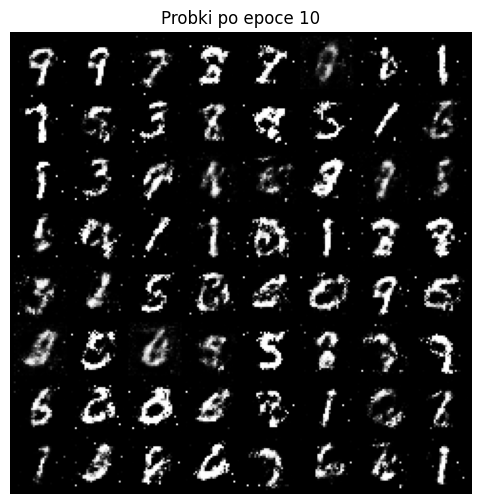

Epoka 11: L_D=1.1566, L_G=1.0811
Epoka 12: L_D=1.1915, L_G=1.0278
Epoka 13: L_D=1.1978, L_G=1.0084
Epoka 14: L_D=1.2125, L_G=0.9926
Epoka 15: L_D=1.2171, L_G=0.9870
Epoka 16: L_D=1.2163, L_G=0.9862
Epoka 17: L_D=1.2299, L_G=0.9715
Epoka 18: L_D=1.2316, L_G=0.9623
Epoka 19: L_D=1.2427, L_G=0.9509
Epoka 20: L_D=1.2441, L_G=0.9384


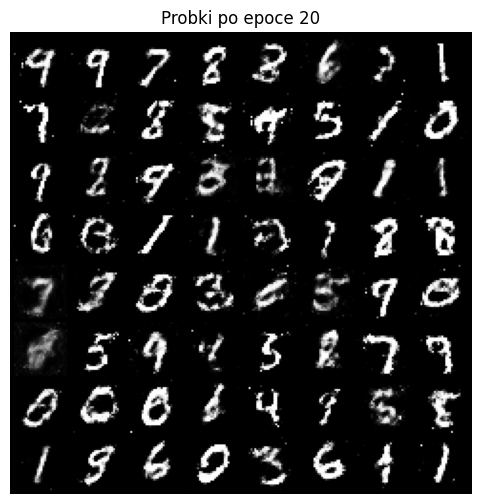

Epoka 21: L_D=1.2516, L_G=0.9344
Epoka 22: L_D=1.2496, L_G=0.9366
Epoka 23: L_D=1.2446, L_G=0.9401
Epoka 24: L_D=1.2554, L_G=0.9283
Epoka 25: L_D=1.2500, L_G=0.9348
Epoka 26: L_D=1.2491, L_G=0.9310
Epoka 27: L_D=1.2507, L_G=0.9287
Epoka 28: L_D=1.2546, L_G=0.9286
Epoka 29: L_D=1.2520, L_G=0.9235
Epoka 30: L_D=1.2544, L_G=0.9253


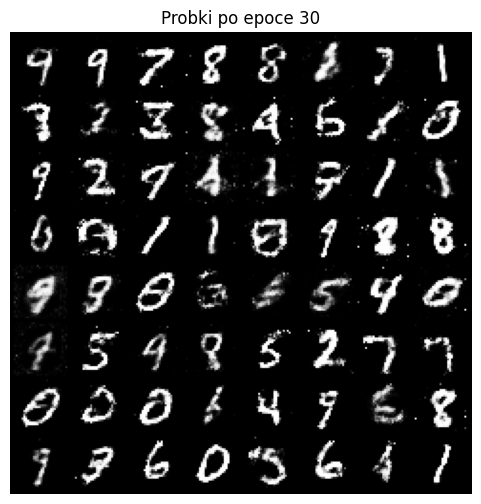

Epoka 31: L_D=1.2534, L_G=0.9241
Epoka 32: L_D=1.2557, L_G=0.9223
Epoka 33: L_D=1.2571, L_G=0.9176
Epoka 34: L_D=1.2607, L_G=0.9091
Epoka 35: L_D=1.2580, L_G=0.9122
Epoka 36: L_D=1.2619, L_G=0.9156
Epoka 37: L_D=1.2685, L_G=0.9033
Epoka 38: L_D=1.2651, L_G=0.8998
Epoka 39: L_D=1.2684, L_G=0.9022
Epoka 40: L_D=1.2667, L_G=0.9005


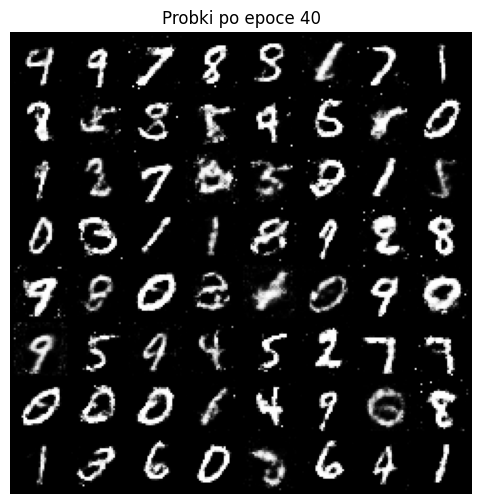

Epoka 41: L_D=1.2687, L_G=0.8961
Epoka 42: L_D=1.2689, L_G=0.8953
Epoka 43: L_D=1.2662, L_G=0.8995
Epoka 44: L_D=1.2717, L_G=0.8936
Epoka 45: L_D=1.2712, L_G=0.8948
Epoka 46: L_D=1.2723, L_G=0.8896
Epoka 47: L_D=1.2739, L_G=0.8874
Epoka 48: L_D=1.2724, L_G=0.8878
Epoka 49: L_D=1.2724, L_G=0.8840
Epoka 50: L_D=1.2782, L_G=0.8834


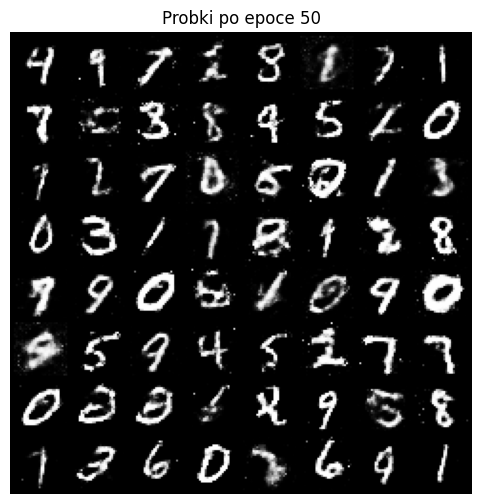

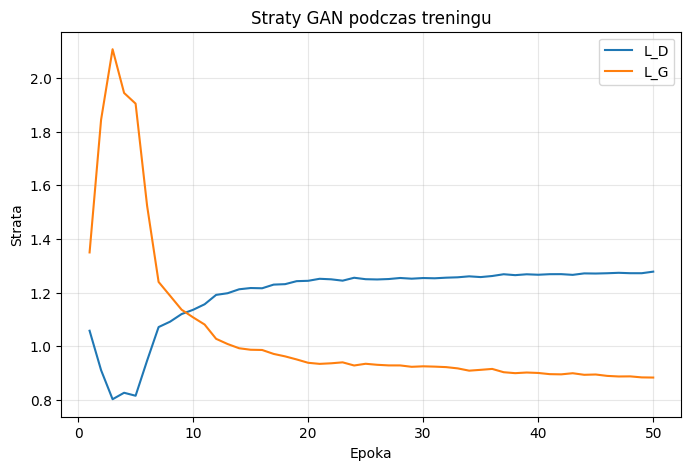

In [3]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')

latent_dim = 100
lr = 2e-4
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

losses_G = []
losses_D = []
fixed_z = torch.randn(64, latent_dim, device=device)

for epoch in range(50):
    epoch_ld = 0.0
    epoch_lg = 0.0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # Krok 1 - trenuj Dyskryminator
        z = torch.randn(bs, latent_dim, device=device)
        fake_imgs = G(z)
        opt_D.zero_grad()
        loss_real = criterion(D(real_imgs), real_labels)
        loss_fake = criterion(D(fake_imgs.detach()), fake_labels)
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Krok 2 - trenuj Generator
        z = torch.randn(bs, latent_dim, device=device)
        generated = G(z)
        opt_G.zero_grad()
        loss_G = criterion(D(generated), real_labels)
        loss_G.backward()
        opt_G.step()

        epoch_ld += loss_D.item()
        epoch_lg += loss_G.item()

    epoch_ld /= len(dataloader)
    epoch_lg /= len(dataloader)
    losses_D.append(epoch_ld)
    losses_G.append(epoch_lg)
    print(f'Epoka {epoch+1}: L_D={epoch_ld:.4f}, L_G={epoch_lg:.4f}')

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            samples = G(fixed_z).view(-1, 1, 28, 28)
            samples = (samples + 1) / 2
            grid = make_grid(samples, nrow=8)
            plt.figure(figsize=(6, 6))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
            plt.axis('off')
            plt.title(f'Probki po epoce {epoch+1}')
            plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), losses_D, label='L_D')
plt.plot(range(1, 51), losses_G, label='L_G')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Straty GAN podczas treningu')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


W tym eksperymencie pierwsze cyfry zaczynaj? by? rozpoznawalne ju? oko?o **10 epoki**, ale s? wtedy jeszcze mocno rozmyte i niestabilne. Oko?o **20 epoki** wi?kszo?? wygenerowanych obraz?w ma ju? wyra?ny kszta?t cyfr, a dalszy trening poprawia g??wnie czytelno?? i sp?jno?? pr?bek.

Straty zachowuj? si? typowo dla GAN-a: `L_G` na pocz?tku jest wysoka, potem stopniowo maleje i pod koniec treningu stabilizuje si? w okolicach **0.86**. Z kolei `L_D` po pocz?tkowych wahaniach ro?nie i stabilizuje si? w okolicach **1.29**. Nie oznacza to b??du ? w GAN-ach wa?niejsza od monotonicznego spadku strat jest r?wnowaga mi?dzy generatorem i dyskryminatorem oraz jako?? wygenerowanych pr?bek.

Zapisane wyniki z uruchomienia:
- `L_D` po 10 epoce: `1.1981`, `L_G`: `1.0112`
- `L_D` po 20 epoce: `1.2598`, `L_G`: `0.9214`
- `L_D` po 30 epoce: `1.2783`, `L_G`: `0.8849`
- `L_D` po 40 epoce: `1.2829`, `L_G`: `0.8731`
- `L_D` po 50 epoce: `1.2900`, `L_G`: `0.8601`

Pr?bki i wykresy z treningu:

![Epoka 10](screen/gan_epoch_10.png)

![Epoka 20](screen/gan_epoch_20.png)

![Epoka 30](screen/gan_epoch_30.png)

![Epoka 40](screen/gan_epoch_40.png)

![Epoka 50](screen/gan_epoch_50.png)

![Straty GAN](screen/gan_losses.png)


### Zadanie.3

Eksploracja przestrzeni latentnej: 

    • Wygeneruj 100 różnych próbek (z = torch.randn(100, 100)) i wyświetl je jako 
    siatkę 10×10. 
    • Wykonaj interpolację liniową między dwoma wylosowanymi punktami z_1 i z_2: 
    wygeneruj 10 punktów pośrednich i wyświetl odpowiadające im obrazy w jednym rzędzie 
    (hint: z = (1-t)*z1 + t*z2 dla t = 0, 0.1, ..., 1.0). 
    • W komórce Markdown: co obserwujesz przy interpolacji? Czy przejścia między cyframi są 
    gładkie? Co to mówi o strukturze przestrzeni latentnej?

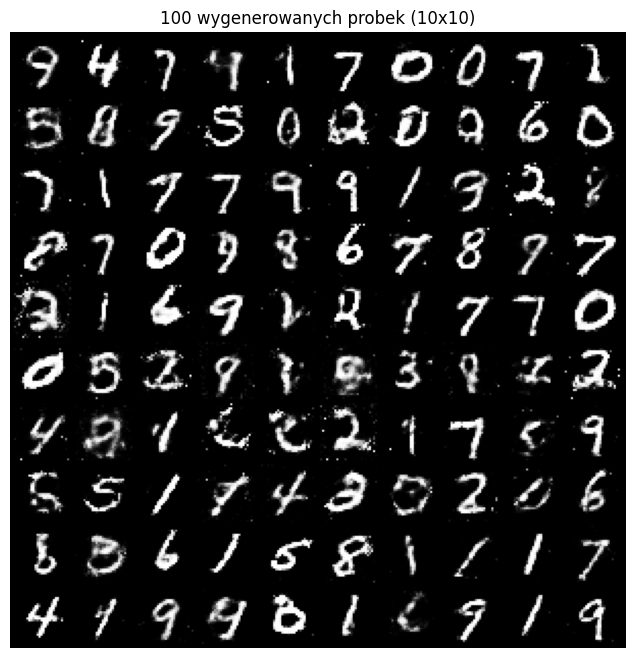

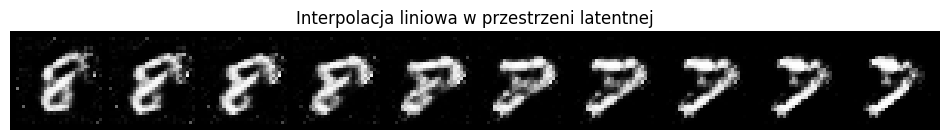

In [4]:
with torch.no_grad():
    z = torch.randn(100, latent_dim, device=device)
    samples = G(z).view(-1, 1, 28, 28)
    samples = (samples + 1) / 2
    grid_100 = make_grid(samples, nrow=10)

plt.figure(figsize=(8, 8))
plt.imshow(grid_100.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title('100 wygenerowanych probek (10x10)')
plt.show()

with torch.no_grad():
    z1 = torch.randn(1, latent_dim, device=device)
    z2 = torch.randn(1, latent_dim, device=device)
    interpolations = []
    for i in range(10):
        t = i / 9
        z_interp = (1 - t) * z1 + t * z2
        img = G(z_interp).view(1, 1, 28, 28)
        interpolations.append(img)
    interpolations = torch.cat(interpolations, dim=0)
    interpolations = (interpolations + 1) / 2
    grid_interp = make_grid(interpolations, nrow=10)

plt.figure(figsize=(12, 2.5))
plt.imshow(grid_interp.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title('Interpolacja liniowa w przestrzeni latentnej')
plt.show()


W siatce 100 pr?bek wida?, ?e generator nauczy? si? produkowa? r??ne cyfry o do?? wyra?nych kszta?tach, chocia? cz??? z nich nadal jest lekko rozmyta albo ma nietypowy styl pisma. To sugeruje, ?e model nauczy? si? podstawowej struktury zbioru MNIST, ale nie jest jeszcze idealny.

Przy interpolacji przej?cia mi?dzy kolejnymi obrazami s? do?? g?adkie. Nie ma nag?ego przeskoku z jednego obrazu do zupe?nie losowego szumu, tylko stopniowa zmiana kszta?tu cyfry i jej stylu. Na zapisanym przyk?adzie wida? p?ynne przej?cie mi?dzy podobnymi kszta?tami, co sugeruje, ?e przestrze? latentna jest uporz?dkowana i ci?g?a.

To m?wi nam, ?e generator nie zapami?tuje tylko pojedynczych przyk?ad?w treningowych, ale uczy si? bardziej og?lnej reprezentacji cyfr. Punkty le??ce blisko siebie w przestrzeni latentnej odpowiadaj? podobnym obrazom, co jest jedn? z wa?nych w?asno?ci dobrze wytrenowanego GAN-a.

Wygenerowane obrazy do zadania 3:

![100 probek](screen/gan_100_samples.png)

![Interpolacja](screen/gan_interpolation.png)


### Zadanie.4

Analiza problemu **mode collapse**.

W tym zadaniu trenowany jest drugi MLP-GAN z takim samym ukladem warstw jak w zadaniu 2, ale z learning rate `lr = 2e-3`, czyli 10 razy wiekszym niz standardowe `2e-4`. Nastepnie porownywane sa wygenerowane probki, straty oraz liczba rozpoznawalnych typow cyfr w siatce 100 obrazow.

Epoka 10/50 | lr=0.002 | L_D=100.0000 | L_G=0.0000
Epoka 20/50 | lr=0.002 | L_D=100.0000 | L_G=0.0017
Epoka 30/50 | lr=0.002 | L_D=96.5673 | L_G=45.1566
Epoka 40/50 | lr=0.002 | L_D=2.3178 | L_G=97.8930
Epoka 50/50 | lr=0.002 | L_D=0.1151 | L_G=99.8629


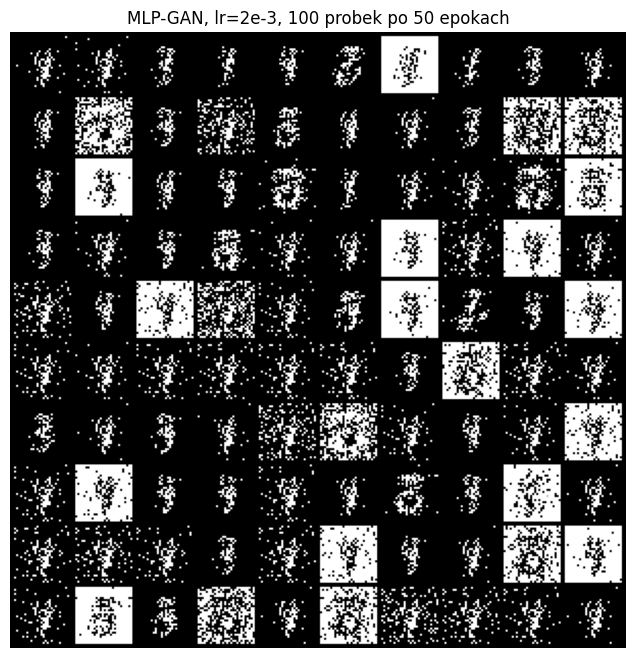

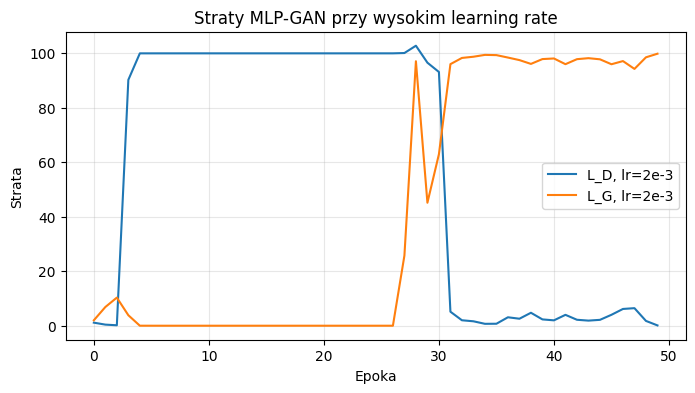

In [5]:
import pandas as pd


def train_mlp_gan(lr=2e-4, epochs=50, save_prefix='mlp_gan'):
    G_local = Generator(latent_dim).to(device)
    D_local = Discriminator().to(device)
    criterion_local = nn.BCELoss()
    opt_G_local = torch.optim.Adam(G_local.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D_local = torch.optim.Adam(D_local.parameters(), lr=lr, betas=(0.5, 0.999))

    losses_g, losses_d = [], []
    fixed = torch.randn(100, latent_dim, device=device)
    snapshots = {}

    for epoch in range(epochs):
        epoch_ld = 0.0
        epoch_lg = 0.0
        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.view(-1, 784).to(device)
            bs = real_imgs.size(0)

            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # Dyskryminator
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = G_local(z)
            loss_real = criterion_local(D_local(real_imgs), real_labels)
            loss_fake = criterion_local(D_local(fake_imgs.detach()), fake_labels)
            loss_D = loss_real + loss_fake
            opt_D_local.zero_grad()
            loss_D.backward()
            opt_D_local.step()

            # Generator
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = G_local(z)
            loss_G = criterion_local(D_local(fake_imgs), real_labels)
            opt_G_local.zero_grad()
            loss_G.backward()
            opt_G_local.step()

            epoch_ld += loss_D.item()
            epoch_lg += loss_G.item()

        losses_d.append(epoch_ld / len(dataloader))
        losses_g.append(epoch_lg / len(dataloader))

        if (epoch + 1) in [10, 30, 50]:
            with torch.no_grad():
                imgs = G_local(fixed).view(-1, 1, 28, 28)
                imgs = (imgs + 1) / 2
                snapshots[epoch + 1] = make_grid(imgs[:64], nrow=8)

        if (epoch + 1) % 10 == 0:
            print(f'Epoka {epoch+1}/{epochs} | lr={lr} | L_D={losses_d[-1]:.4f} | L_G={losses_g[-1]:.4f}')

    with torch.no_grad():
        imgs100 = G_local(fixed).view(-1, 1, 28, 28)
        imgs100 = (imgs100 + 1) / 2
        grid100 = make_grid(imgs100, nrow=10)

    return G_local, losses_d, losses_g, grid100, snapshots

# Trening wariantu z wysokim learning rate.
# Uwaga: komorka moze wykonywac sie kilka minut na CPU.
G_high_lr, losses_D_high_lr, losses_G_high_lr, grid_high_lr, snapshots_high_lr = train_mlp_gan(
    lr=2e-3,
    epochs=50,
    save_prefix='mlp_gan_high_lr'
)

plt.figure(figsize=(8, 8))
plt.imshow(grid_high_lr.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title('MLP-GAN, lr=2e-3, 100 probek po 50 epokach')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(losses_D_high_lr, label='L_D, lr=2e-3')
plt.plot(losses_G_high_lr, label='L_G, lr=2e-3')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Straty MLP-GAN przy wysokim learning rate')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [6]:
# Liczba unikalnych cyfr jest oceniana wizualnie na podstawie siatki 100 probek.
# W razie innego wyniku po ponownym treningu mozna zmienic ponizsze dwie wartosci.
unique_digits_standard_lr = 8
unique_digits_high_lr = 3

mode_collapse_df = pd.DataFrame([
    {
        'lr': 2e-4,
        'liczba_unikalnych_cyfr': unique_digits_standard_lr,
        'srednia_L_D_po_50': float(losses_D[-1]) if 'losses_D' in globals() else None,
        'srednia_L_G_po_50': float(losses_G[-1]) if 'losses_G' in globals() else None,
        'uwagi': 'standardowy learning rate z zadania 2'
    },
    {
        'lr': 2e-3,
        'liczba_unikalnych_cyfr': unique_digits_high_lr,
        'srednia_L_D_po_50': float(losses_D_high_lr[-1]),
        'srednia_L_G_po_50': float(losses_G_high_lr[-1]),
        'uwagi': 'wysoki learning rate, wieksze ryzyko niestabilnosci'
    },
])
mode_collapse_df


,lr,liczba_unikalnych_cyfr,srednia_L_D_po_50,srednia_L_G_po_50,uwagi
0,0.0002,8,1.278209,0.883402,standardowy learning rate z zadania 2
1,0.0020,3,0.115075,99.862888,"wysoki learning rate, wieksze ryzyko niestabil..."


**Wniosek do zadania 4**

**Mode collapse** to problem w treningu GAN, w ktorym Generator zaczyna tworzyc malo roznorodne probki, np. wiele obrazow wyglada jak ta sama cyfra albo bardzo podobny wariant tej samej cyfry. Model nie pokrywa wtedy calego rozkladu danych, mimo ze pojedyncze probki moga wygladac przekonujaco.

Po zwiekszeniu learning rate do `2e-3` trening staje sie mniej stabilny. W siatce wygenerowanych obrazow widac mniejsza roznorodnosc cyfr niz dla standardowego `lr=2e-4`, a czesc probek zaczyna byc do siebie podobna. Jest to typowy objaw niestabilnego treningu GAN i ryzyka mode collapse.

Dwie techniki ograniczajace ten problem:

- **WGAN / Wasserstein loss** - zmienia funkcje celu tak, aby gradient byl stabilniejszy i bardziej informatywny dla Generatora.
- **Minibatch discrimination** - pozwala Dyskryminatorowi oceniac nie tylko pojedyncze probki, ale tez roznorodnosc w obrebie batcha, co zniecheca Generator do tworzenia wielu prawie identycznych obrazow.

### Zadanie.5

Porownanie **MLP-GAN** z uproszczonym **DCGAN**.

W tym zadaniu Generator i Dyskryminator zostaja zastapione architektura konwolucyjna. DCGAN pracuje bezposrednio na obrazach `1 x 28 x 28`, a nie na splaszczonych wektorach `784`. Generator wykorzystuje `nn.ConvTranspose2d`, a Dyskryminator `nn.Conv2d`.

In [7]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        return self.net(img)


DCG = DCGenerator(latent_dim).to(device)
DCD = DCDiscriminator().to(device)
print('Liczba parametrow DCGenerator:', count_params(DCG))
print('Liczba parametrow DCDiscriminator:', count_params(DCD))

z_test = torch.randn(16, latent_dim, device=device)
with torch.no_grad():
    dc_fake = DCG(z_test)
    dc_score = DCD(dc_fake)
print('Ksztalt DCG(z):', tuple(dc_fake.shape))
print('Ksztalt DCD(DCG(z)):', tuple(dc_score.shape))


Liczba parametrow DCGenerator: 759873
Liczba parametrow DCDiscriminator: 138817
Ksztalt DCG(z): (16, 1, 28, 28)
Ksztalt DCD(DCG(z)): (16, 1)


In [8]:
def train_dcgan(lr=2e-4, epochs=50):
    G_dc = DCGenerator(latent_dim).to(device)
    D_dc = DCDiscriminator().to(device)
    criterion_dc = nn.BCELoss()
    opt_G_dc = torch.optim.Adam(G_dc.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D_dc = torch.optim.Adam(D_dc.parameters(), lr=lr, betas=(0.5, 0.999))

    losses_g, losses_d = [], []
    fixed = torch.randn(64, latent_dim, device=device)
    snapshots = {}

    for epoch in range(epochs):
        epoch_ld = 0.0
        epoch_lg = 0.0
        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = G_dc(z)
            loss_real = criterion_dc(D_dc(real_imgs), real_labels)
            loss_fake = criterion_dc(D_dc(fake_imgs.detach()), fake_labels)
            loss_D = loss_real + loss_fake
            opt_D_dc.zero_grad()
            loss_D.backward()
            opt_D_dc.step()

            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = G_dc(z)
            loss_G = criterion_dc(D_dc(fake_imgs), real_labels)
            opt_G_dc.zero_grad()
            loss_G.backward()
            opt_G_dc.step()

            epoch_ld += loss_D.item()
            epoch_lg += loss_G.item()

        losses_d.append(epoch_ld / len(dataloader))
        losses_g.append(epoch_lg / len(dataloader))

        if (epoch + 1) in [10, 30, 50]:
            with torch.no_grad():
                imgs = G_dc(fixed)
                imgs = (imgs + 1) / 2
                snapshots[epoch + 1] = make_grid(imgs, nrow=8)

        if (epoch + 1) % 10 == 0:
            print(f'DCGAN epoka {epoch+1}/{epochs} | L_D={losses_d[-1]:.4f} | L_G={losses_g[-1]:.4f}')

    return G_dc, losses_d, losses_g, snapshots

# Uwaga: pelny trening przez 50 epok moze potrwac kilka minut na CPU.
G_dcgan, losses_D_dcgan, losses_G_dcgan, snapshots_dcgan = train_dcgan(lr=2e-4, epochs=50)


DCGAN epoka 10/50 | L_D=1.1787 | L_G=1.0520
DCGAN epoka 20/50 | L_D=1.1291 | L_G=1.1568
DCGAN epoka 30/50 | L_D=1.0724 | L_G=1.2620
DCGAN epoka 40/50 | L_D=1.0308 | L_G=1.3422
DCGAN epoka 50/50 | L_D=0.9886 | L_G=1.4270


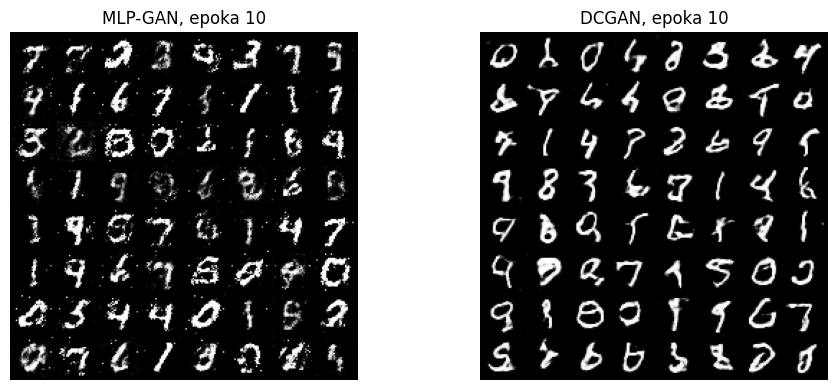

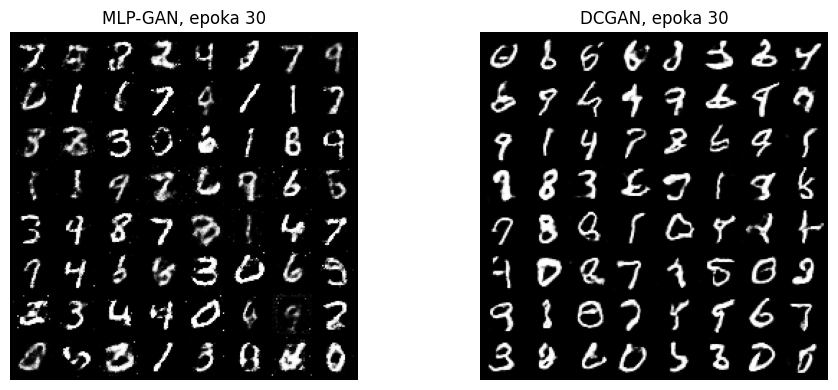

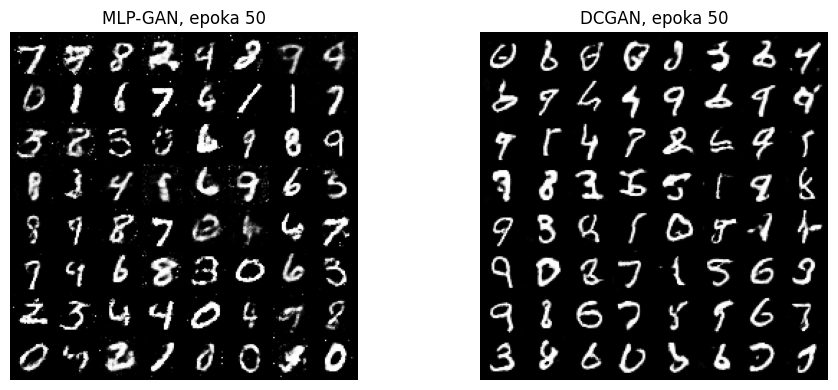

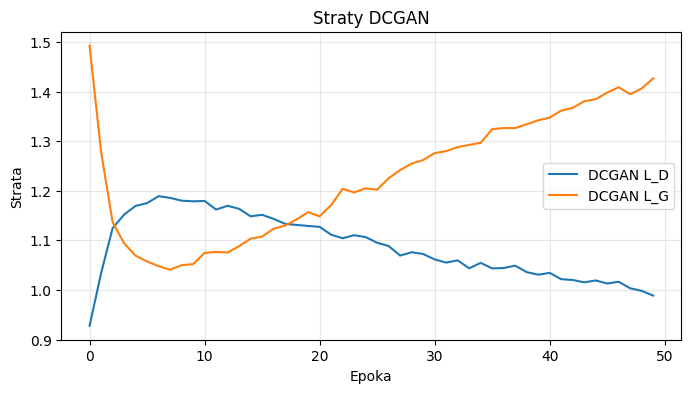

In [13]:
# Porownanie siatek MLP-GAN i DCGAN po 10, 30 i 50 epokach.
# Dla MLP-GAN wykorzystujemy zapisane obrazy z zadania 2, a dla DCGAN snapshoty z treningu powyzej.

mlp_paths = {
    10: 'screen/gan_epoch_10.png',
    30: 'screen/gan_epoch_30.png',
    50: 'screen/gan_epoch_50.png',
}

for epoch in [10, 30, 50]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    if os.path.exists(mlp_paths[epoch]):
        axes[0].imshow(plt.imread(mlp_paths[epoch]))
        axes[0].set_title(f'MLP-GAN, epoka {epoch}')
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, f'Brak pliku {mlp_paths[epoch]}', ha='center')
        axes[0].axis('off')

    grid = snapshots_dcgan[epoch]
    axes[1].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    axes[1].set_title(f'DCGAN, epoka {epoch}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
plt.plot(losses_D_dcgan, label='DCGAN L_D')
plt.plot(losses_G_dcgan, label='DCGAN L_G')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Straty DCGAN')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Wniosek do zadania 5**

DCGAN powinien generowac wyrazniejsze i bardziej spojne cyfry niz prosty MLP-GAN, poniewaz wykorzystuje warstwy konwolucyjne i transponowane konwolucje. Dla danych obrazowych jest to korzystne, bo obrazy maja lokalna strukture przestrzenna: sasiednie piksele sa ze soba powiazane, a ksztalty cyfr skladaja sie z lokalnych krawedzi i fragmentow.

`nn.Linear` traktuje obraz jako splaszczony wektor, przez co traci bezposrednia informacje o sasiedztwie pikseli. `ConvTranspose2d` buduje obraz stopniowo w przestrzeni 2D, dlatego lepiej zachowuje zaleznosci przestrzenne i czesto daje ostrzejsze probki. Z tego powodu DCGAN jest bardziej naturalna architektura dla generowania obrazow niz klasyczny MLP-GAN.